This notebook defines a series of functions that match parks to their associated LiDAR tile sets, for the England Defra dataset. Note the matching for the Wales dataset is different as the data is provided in a composite single mosaic; slicing of this has to be done manually and isn't dealt with in this notebook.

This includes functions/code that:

- Checks that the same number of tiff files exist as zip files
- Plots a quick check of spatial coverage (tiles available vs area)
- Given a bounding box, return the tile code(s) that cover that area
    - Also, return the matching file names from provided dir that match that code


The LiDAR dataset uses the following naming convention: `[OS_10km_Grid][Quarter_Sheet]_[Product]_[Resolution]`, as descibed in [this tutorial sheet](https://historicengland.org.uk/content/docs/research/using-ea-lidar-data-pdf/) from Historic England.

I'm using bounding boxes with the following convention:

![alt text](image.png)

```
[-1.568899,53.807367,-1.552892,53.815171]
[long, lat, long lat]
```

However you should run a check at the beginning before matching tiles etc. to ensure you don't need to convert/rotate/re-order bounding box coordinates.

For guidance on the converting to the OS grid, see this [Digimap's post](https://digimap.edina.ac.uk/help/our-maps-and-data/bng/) and the [Ordnance Survey coordinate transformations page](https://www.ordnancesurvey.co.uk/geodesy-positioning/coordinate-transformations):

>Grid References consist of:
>- two letters, optionally followed by
>- an even number of digits, optionally followed by
>- a quadrant name: “NW”, “NE”, “SW” or “SE”, standing for North West, North East, South West and South East.
>
>To convert a National Grid Reference to Eastings and Northings:
>1. Remove the two letters at the beginning of the reference: e.g. NS1234 becomes 1234
>2. Split the reference into its East and North components: e.g. 12 East and 34 North
>3. Work out the numerical reference for the two letters: e.g. NS = 200km East and 600km North.
>4. Use the diagram below to calculate how many 100km units east and north the bottom left hand corner of your square is. For example, square NS is 200km East and 600km North of the origin, which becomes 2 units East and 6 units North.
>5. Add the appropriate 100km reference to the beginning of the rest of the reference (remembering to omit the letters): e.g. 212 East and 634 North.
>Example: 10km (2-figure) Grid Reference: SO84 = 380000 Easting 240000 Northing


In [1]:
# imports
import os
import geopandas as gpd
from shapely.geometry import box
from pyproj import Transformer


# for plotting/checking
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import numpy as np

In [2]:
# folder path for checking tile coverage
# can be either DTM or DSM tiles; can do both to ensure matching datasets

path_dtm = "/Volumes/Extreme SSD/DTM"

# first, check how many zip archives in the folder
# need to exclude files that begin with ._, which are hidden files created by macOS
zip_files = [f for f in os.listdir(path_dtm) if f.endswith('.zip') and not f.startswith('._')]
# can use this as a check to ensure all tiles have been extracted

# create a list of all the DTM tile names (all files in the folder with a .tif extension)
dtm_tiles = [f for f in os.listdir(path_dtm) if f.endswith('.tif') and not f.startswith('._')]

In [3]:
print(len(zip_files))
print(len(dtm_tiles))

print(dtm_tiles[:5])

5877
5877
['NT60se_DTM_2m.tif', 'NT60ne_DTM_2m.tif', 'NT60sw_DTM_2m.tif', 'NT70ne_DTM_2m.tif', 'NT70nw_DTM_2m.tif']


In [4]:
# create a list of tile coords from the tile names
# e.g. need to drop everything from the _ onwards

tile_coords = [f.split('_')[0] for f in dtm_tiles]

In [5]:
tile_coords[:5]

['NT60se', 'NT60ne', 'NT60sw', 'NT70ne', 'NT70nw']

In [6]:
# Example bounding box

bbox_list = [-1.568899,53.807367,-1.552892,53.815171]

# convert to a geoseries for spatial operations

bbox = gpd.GeoSeries(box(*bbox_list), crs="EPSG:4326")

<Axes: >

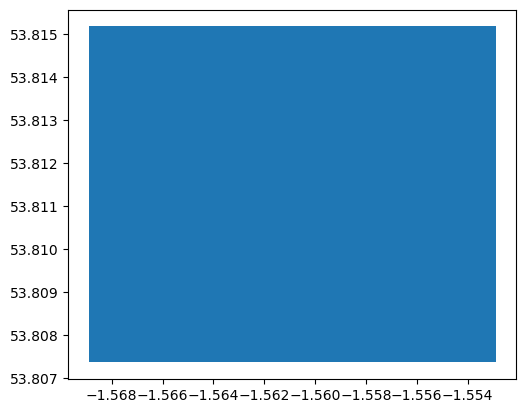

In [7]:
bbox.plot()

# just checking that order/location of bounding corners matched expectations

In [8]:
bbox

0    POLYGON ((-1.55289 53.80737, -1.55289 53.81517...
dtype: geometry

In [9]:
print(bbox[0])

POLYGON ((-1.552892 53.807367, -1.552892 53.815171, -1.568899 53.815171, -1.568899 53.807367, -1.552892 53.807367))


The five points in the bounding box are:

- Bottom-left corner
- Bottom-right corner
- Top-right corner
- Top-left corner
- Back to the starting point (bottom-left again) to close the ring

In [10]:
print(bbox[0].exterior.coords[0])
print(bbox[0].exterior.coords[1])
print(bbox[0].exterior.coords[2])
print(bbox[0].exterior.coords[3])

(-1.552892, 53.807367)
(-1.552892, 53.815171)
(-1.568899, 53.815171)
(-1.568899, 53.807367)


Taking the diagonal corners and checking the individual points to grid ref conversion:

In [11]:
example_point1 = bbox[0].exterior.coords[0]
example_point2 = bbox[0].exterior.coords[2]
print(example_point1, example_point2)

(-1.552892, 53.807367) (-1.568899, 53.815171)


In [12]:
def latlon_to_os_grid(latitude, longitude, include_quadrant=True):
    """
    Convert a single latitude/longitude point to an OS grid reference.
    
    Parameters:
    -----------
    latitude : float
        Latitude in degrees (WGS84)
    longitude : float
        Longitude in degrees (WGS84)
    include_quadrant : bool
        If True, returns quadrant (ne, nw, se, sw). If False, returns basic 10km reference.
        
    Returns:
    --------
    str : OS grid reference (e.g., 'SD50' or 'SD50ne')
    """
    
    # Convert lat/lon to OS National Grid (Easting, Northing)
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True)
    easting, northing = transformer.transform(longitude, latitude)
    
    # OS National Grid letters (500km and 100km squares)
    first_letters = ['S', 'T', 'N', 'O', 'H']
    second_letters = ['V', 'W', 'X', 'Y', 'Z',
                      'Q', 'R', 'S', 'T', 'U',
                      'L', 'M', 'N', 'O', 'P',
                      'F', 'G', 'H', 'J', 'K',
                      'A', 'B', 'C', 'D', 'E']
    
    # Calculate 500km grid square
    e_500 = int(easting / 500000)
    n_500 = int(northing / 500000)
    
    # Calculate 100km grid square within the 500km square
    e_100 = int((easting % 500000) / 100000)
    n_100 = int((northing % 500000) / 100000)
    
    # Get grid letters
    try:
        first_letter = first_letters[n_500 * 2 + e_500]
        second_letter = second_letters[n_100 * 5 + e_100]
    except IndexError:
        return None  # Outside GB
    
    # Get position within the 100km square (in km)
    e_within_100km = (easting % 100000) / 1000
    n_within_100km = (northing % 100000) / 1000
    
    # Get 10km position within the 100km square
    e_10km = int(e_within_100km / 10)
    n_10km = int(n_within_100km / 10)
    
    grid_ref = f"{first_letter}{second_letter}{e_10km}{n_10km}"
    
    if include_quadrant:
        # Determine quadrant based on position within 10km square
        # Each 10km square subdivides into 4 quadrants of 5km each
        e_is_east = (e_within_100km % 10) >= 5
        n_is_north = (n_within_100km % 10) >= 5
        
        if e_is_east:  # East half
            if n_is_north:  # North half
                quadrant = 'ne'
            else:  # South half
                quadrant = 'se'
        else:  # West half
            if n_is_north:  # North half
                quadrant = 'nw'
            else:  # South half
                quadrant = 'sw'
        
        grid_ref += quadrant
    
    return grid_ref

In [13]:
# nb - note the order of the arguments
example_grid1 = latlon_to_os_grid(example_point1[1], example_point1[0], include_quadrant=True)
example_grid2 = latlon_to_os_grid(example_point2[1], example_point2[0], include_quadrant=True)
print(example_grid1, example_grid2)


SE23se SE23ne


In [14]:
# bounding box calculations
# we can assume that no park in this dataset will stretch across the full width of a tile
# so the max number of tiles could be 4 (if the park is at the corner)
# So we can calculate the grid reference for each corner of the bounding box,
# and then take the unique values from the resulting list of references

def get_tile_refs_from_bbox(bbox):
    # get the corner points of the bounding box
    corners = [bbox[0].exterior.coords[i] for i in range(4)]
    # print(corners) # for dev, but remove for scaling up.

    # convert each corner to a grid reference
    grid_refs = [latlon_to_os_grid(corner[1], corner[0], include_quadrant=True) for corner in corners]
    
    # return unique grid references
    return set(grid_refs)

In [15]:
get_tile_refs_from_bbox(bbox)

{'SE23ne', 'SE23se'}

Checking tile coverage - using the grid tiles present in the folder path to check coverage across the study area.

In [16]:
# uk bounds - rough, for simple map

uk_bounds = (0, 0, 700000, 1300000)
minx, miny, maxx, maxy = uk_bounds
tile_size = 10000

In [17]:
def easting_northing_to_os_grid(easting, northing, include_quadrant=False):
    """
    Convert easting/northing (EPSG:27700) directly to OS grid reference.
    
    Parameters:
    -----------
    easting : float
        Easting in meters (EPSG:27700)
    northing : float
        Northing in meters (EPSG:27700)
    include_quadrant : bool
        If True, returns quadrant (ne, nw, se, sw). If False, returns basic 10km reference.
        
    Returns:
    --------
    str : OS grid reference (e.g., 'SD50' or 'SD50ne')
    """
    
    first_letters = ['S', 'T', 'N', 'O', 'H']
    second_letters = ['V', 'W', 'X', 'Y', 'Z',
                      'Q', 'R', 'S', 'T', 'U',
                      'L', 'M', 'N', 'O', 'P',
                      'F', 'G', 'H', 'J', 'K',
                      'A', 'B', 'C', 'D', 'E']
    
    e_500 = int(easting / 500000)
    n_500 = int(northing / 500000)
    e_100 = int((easting % 500000) / 100000)
    n_100 = int((northing % 500000) / 100000)
    
    try:
        first_letter = first_letters[n_500 * 2 + e_500]
        second_letter = second_letters[n_100 * 5 + e_100]
    except IndexError:
        return None
    
    e_within_100km = (easting % 100000) / 1000
    n_within_100km = (northing % 100000) / 1000
    e_10km = int(e_within_100km / 10)
    n_10km = int(n_within_100km / 10)
    
    grid_ref = f"{first_letter}{second_letter}{e_10km}{n_10km}"
    
    if include_quadrant:
        e_is_east = (e_within_100km % 10) >= 5
        n_is_north = (n_within_100km % 10) >= 5
        quadrant = ('ne' if e_is_east and n_is_north else
                   'se' if e_is_east else
                   'nw' if n_is_north else 'sw')
        grid_ref += quadrant
    
    return grid_ref

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)


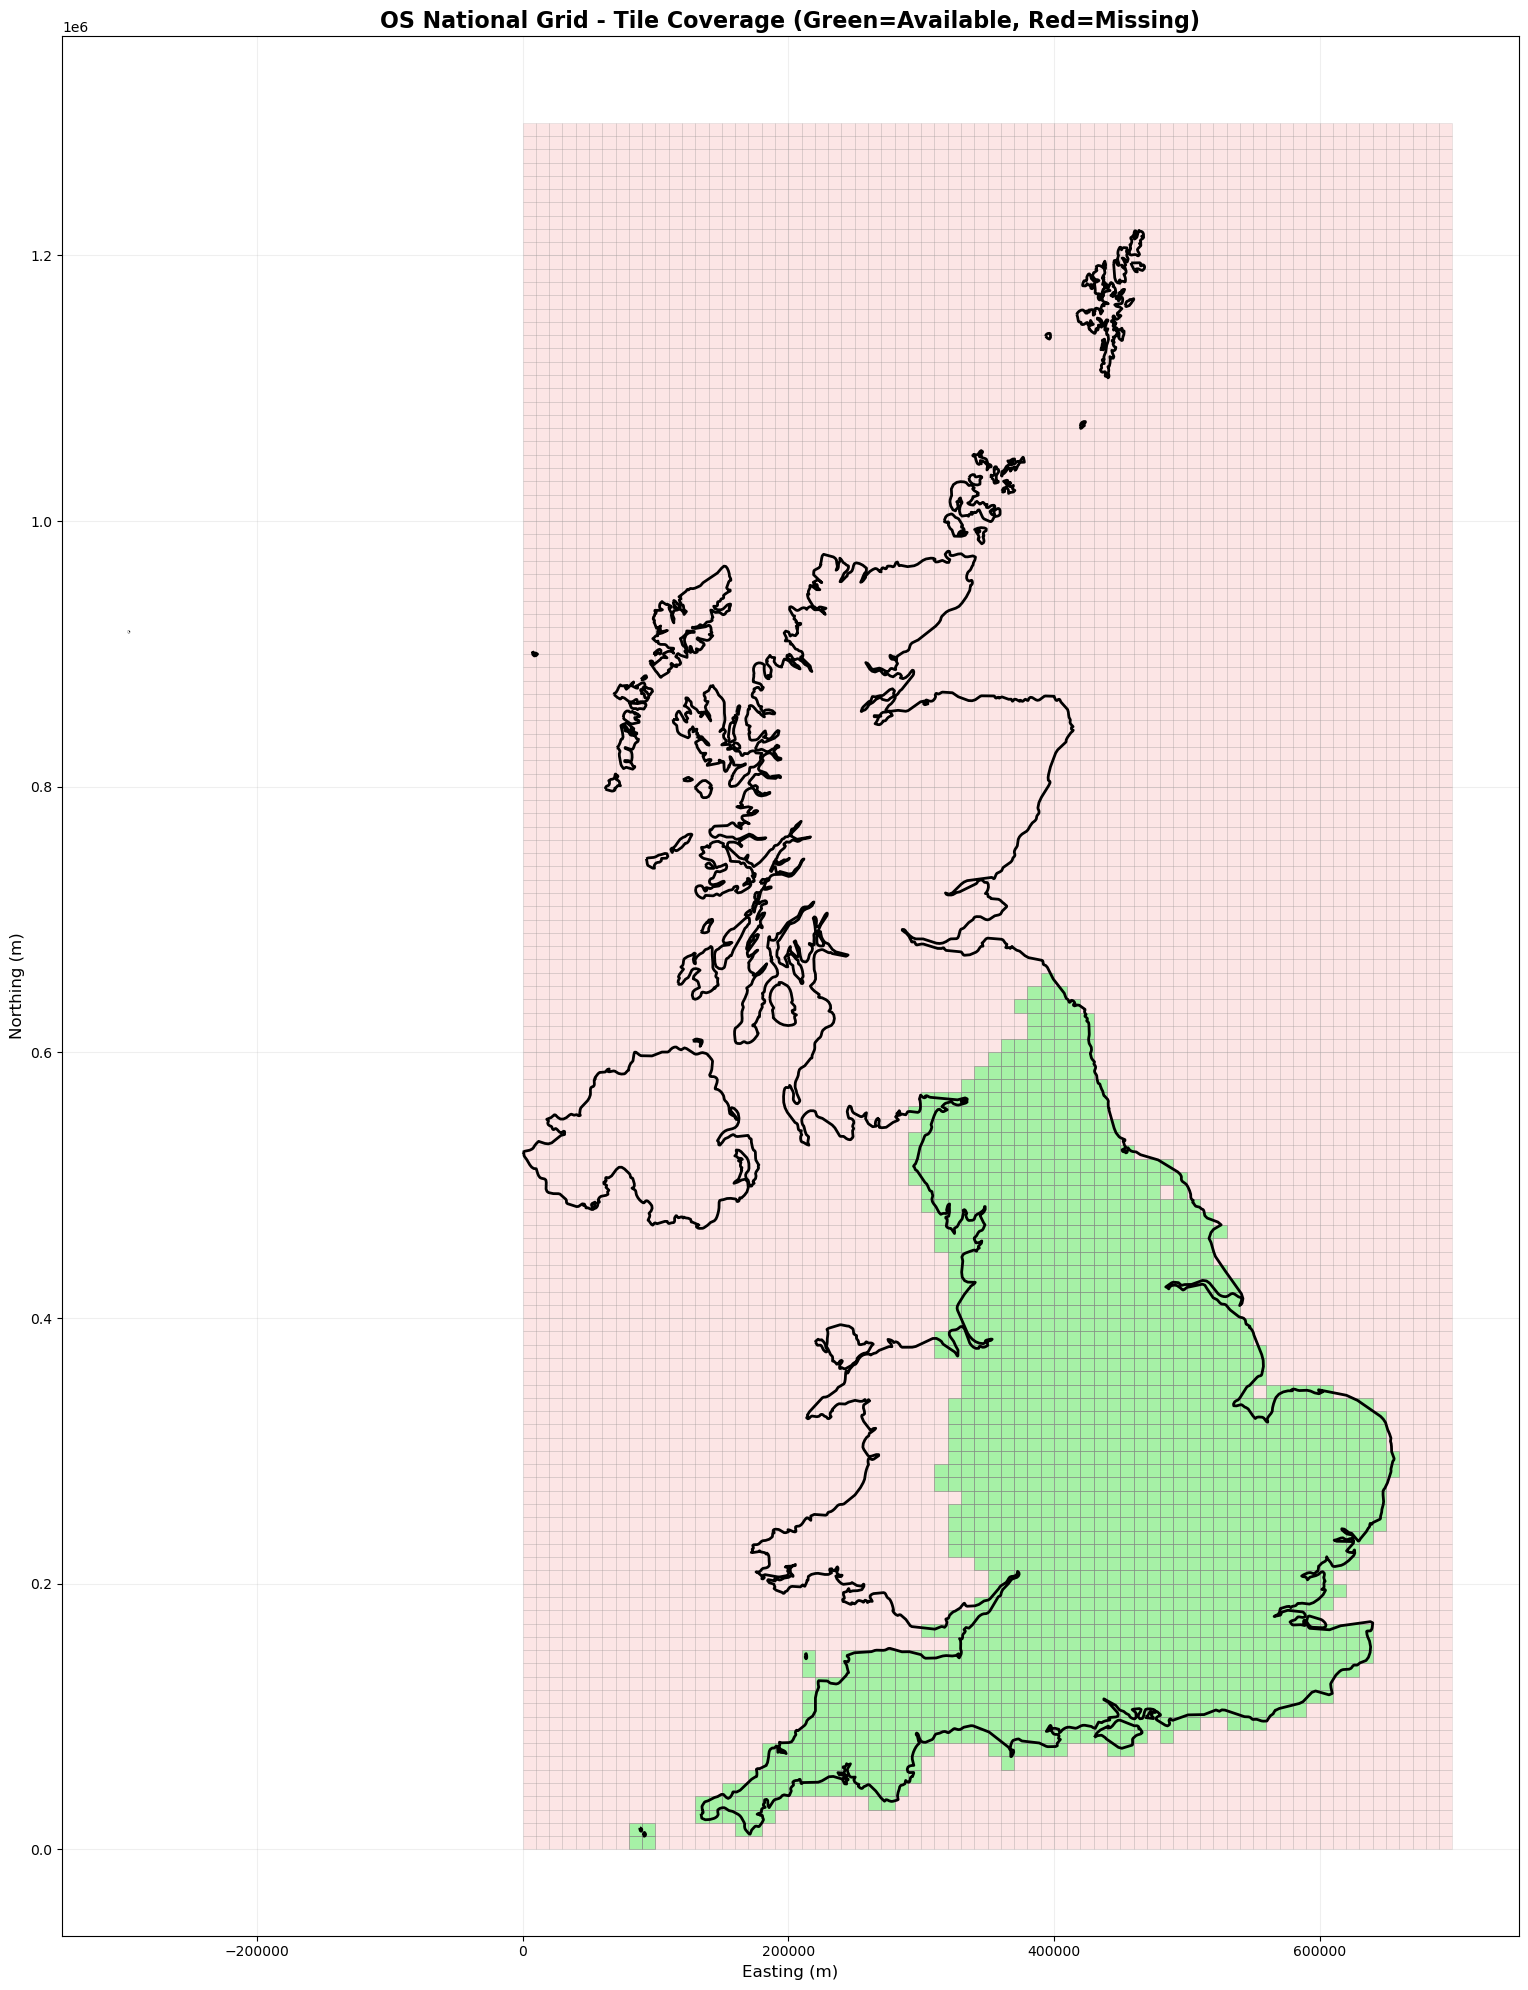

In [19]:
# Download UK boundary from Natural Earth GitHub
url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
uk_data = gpd.read_file(url)

# Check available columns
print(uk_data.columns)

uk = uk_data[uk_data['ADMIN'] == 'United Kingdom']

fig, ax = plt.subplots(figsize=(16, 20))

available_tiles = set(tile_coords)

# Collect polygons and colors
green_polys = []
red_polys = []

for e in range(int(minx), int(maxx), tile_size):
    for n in range(int(miny), int(maxy), tile_size):
        tile_poly = box(e, n, e + tile_size, n + tile_size)
        tile_ref = easting_northing_to_os_grid(e + tile_size/2, n + tile_size/2, include_quadrant=True)
        
        if tile_ref and tile_ref in available_tiles:
            green_polys.append(tile_poly)
        else:
            red_polys.append(tile_poly)

# Plot tiles
if green_polys:
    gpd.GeoSeries(green_polys, crs='EPSG:27700').plot(
        ax=ax, facecolor='lightgreen', edgecolor='gray', linewidth=0.5, alpha=0.8
    )

if red_polys:
    gpd.GeoSeries(red_polys, crs='EPSG:27700').plot(
        ax=ax, facecolor='lightcoral', edgecolor='gray', linewidth=0.5, alpha=0.2
    )

# Plot UK boundary on top
uk_reprojected = uk.to_crs('EPSG:27700')
uk_reprojected.boundary.plot(ax=ax, color='black', linewidth=2)

ax.set_title('OS National Grid - Tile Coverage (Green=Available, Red=Missing)', fontsize=16, fontweight='bold')
ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()